# Preprocessing & EDA

Reddit comments labelled **1** (positive), **0** (neutral) and **-1** (negative).
This dataset stands in for YouTube comments, which are expensive to collect and label.

In [1]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

from src.data.text_cleaning import ensure_nltk_data

ensure_nltk_data()
DATA_URL = 'https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv'

In [2]:
df = pd.read_csv(DATA_URL)
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [3]:
df.shape

(37249, 2)

In [4]:
df.sample(3, random_state=42)['clean_comment'].values

array([' wish shake hands with these people one day ',
       'why are they all fat ',
       'this just being overly dramatic the ramblings the uae foreign minister few months ago about the yemen participation pakistan was just done pressure pakistan into completely aligning with the gulf uae does not and will not make political statements that aren backed the rest the khaleeji countries suggest that uae pursuing more india focused diplomacy political future not true true from purely business perspective which happens the only thing uae rulers care about terms india pakistan relations the whole gwadar port business has pissed off these city states and they are pressuring pakistan abandon since will hurt them economically the use such politics just mask the real issue they have with the port the vague and contradictory stands pakistan and turkey are absolute proof that arab security — from libya yemen — the responsibility none but arab countries that statement cute the gulf arab countr

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


## Missing values, duplicates, empty comments

In [6]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [7]:
# Every missing comment is labelled neutral, and 100 rows out of 37k is safe to drop
df[df['clean_comment'].isna()]['category'].value_counts()

category
0    100
Name: count, dtype: int64

In [8]:
df.dropna(inplace=True)
df.duplicated().sum()

np.int64(350)

In [9]:
df[df.duplicated()].head(10)

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
1528,,0
1613,attention please keep mind that the this thre...,1
1760,jpg,0
1835,,0
1858,jpg,0


In [10]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [11]:
df[df['clean_comment'].str.strip() == '']

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [12]:
df = df[df['clean_comment'].str.strip() != '']

## Basic text normalisation

In [13]:
df['clean_comment'] = df['clean_comment'].str.lower()

# How many comments start or end with whitespace
df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' ')).sum()

np.int64(32266)

In [14]:
df['clean_comment'] = df['clean_comment'].str.strip()
df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' ')).sum()

np.int64(0)

In [15]:
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
df[df['clean_comment'].str.contains(url_pattern, regex=True)].head()

,clean_comment,category


In [16]:
df[df['clean_comment'].str.contains('\n')].head()

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [17]:
df['clean_comment'] = df['clean_comment'].str.replace('\n', ' ', regex=False)
df['clean_comment'].str.contains('\n').sum()

np.int64(0)

## EDA: class balance

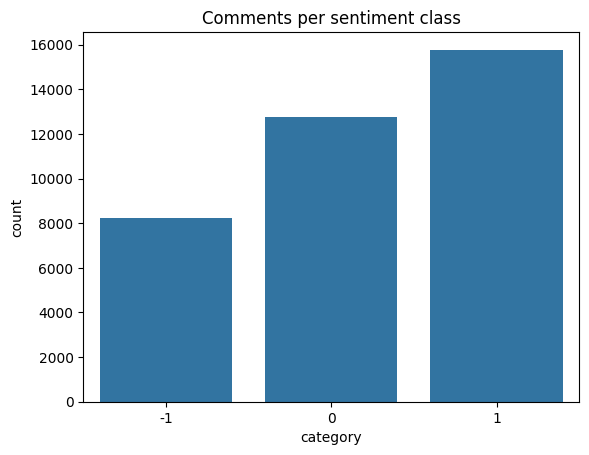

In [18]:
sns.countplot(data=df, x='category')
plt.title('Comments per sentiment class')
plt.show()

In [19]:
# The data is imbalanced: negative comments are the minority class
df['category'].value_counts(normalize=True).mul(100).round(2)

category
 1    42.86
 0    34.71
-1    22.42
Name: proportion, dtype: float64

## EDA: comment length

In [20]:
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))
df['word_count'].describe()

count    36793.000000
mean        29.667464
std         56.790738
min          1.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: word_count, dtype: float64

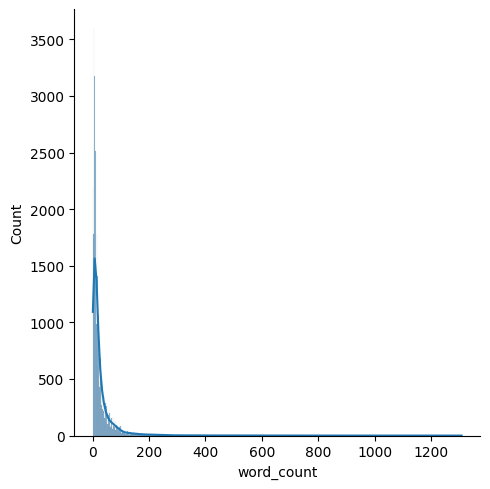

In [21]:
sns.displot(df['word_count'], kde=True)
plt.show()

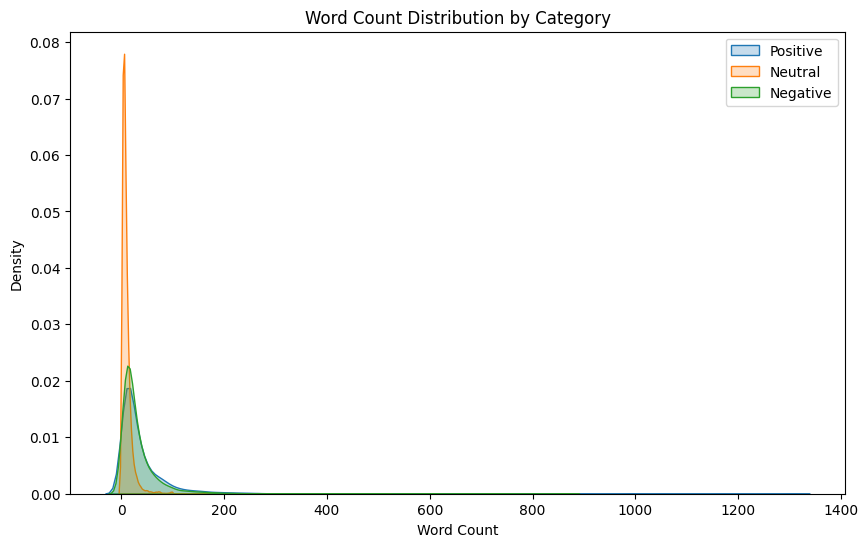

In [22]:
plt.figure(figsize=(10, 6))
for value, label in [(1, 'Positive'), (0, 'Neutral'), (-1, 'Negative')]:
    sns.kdeplot(df[df['category'] == value]['word_count'], label=label, fill=True)
plt.title('Word Count Distribution by Category')
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.legend()
plt.show()

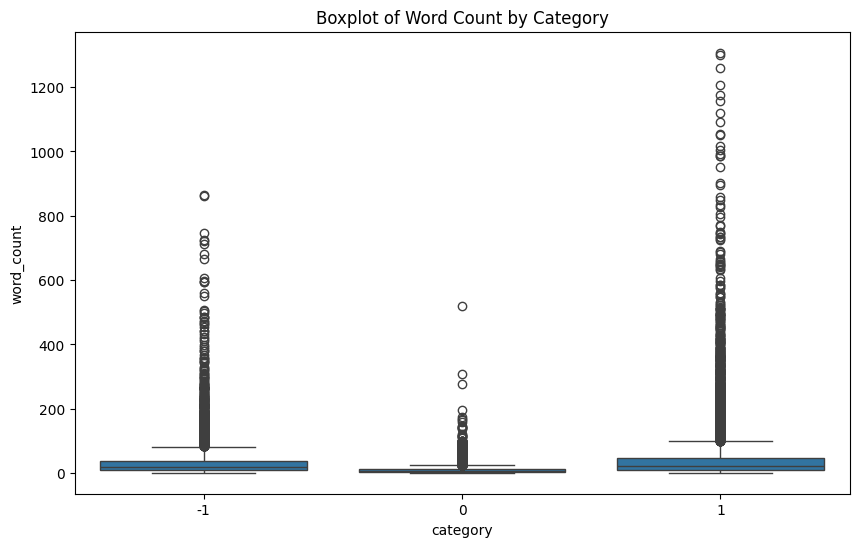

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='word_count')
plt.title('Boxplot of Word Count by Category')
plt.show()

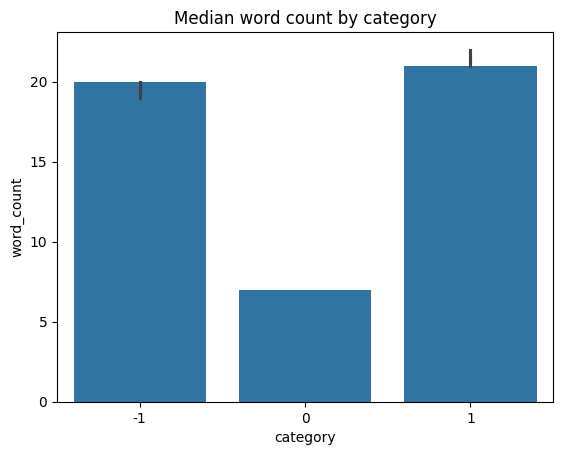

In [24]:
sns.barplot(data=df, x='category', y='word_count', estimator='median')
plt.title('Median word count by category')
plt.show()

Positive comments are the longest and neutral comments the shortest; all classes have long-tail outliers.

## EDA: stop words

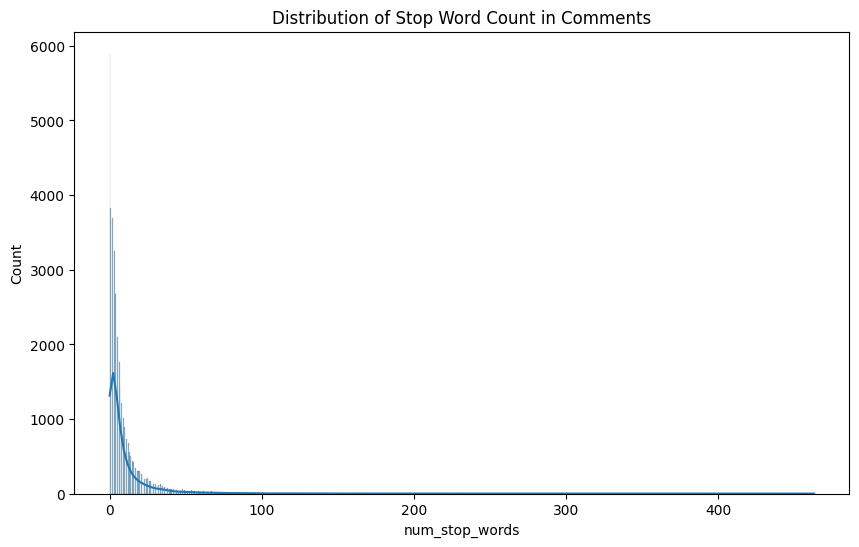

In [25]:
stop_words = set(stopwords.words('english'))
df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([w for w in x.split() if w in stop_words]))

plt.figure(figsize=(10, 6))
sns.histplot(df['num_stop_words'], kde=True)
plt.title('Distribution of Stop Word Count in Comments')
plt.show()

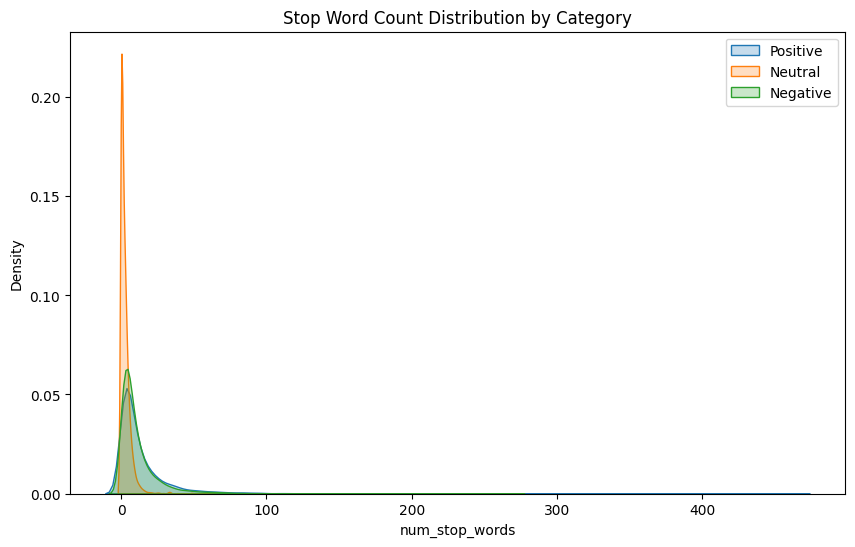

In [26]:
plt.figure(figsize=(10, 6))
for value, label in [(1, 'Positive'), (0, 'Neutral'), (-1, 'Negative')]:
    sns.kdeplot(df[df['category'] == value]['num_stop_words'], label=label, fill=True)
plt.title('Stop Word Count Distribution by Category')
plt.legend()
plt.show()

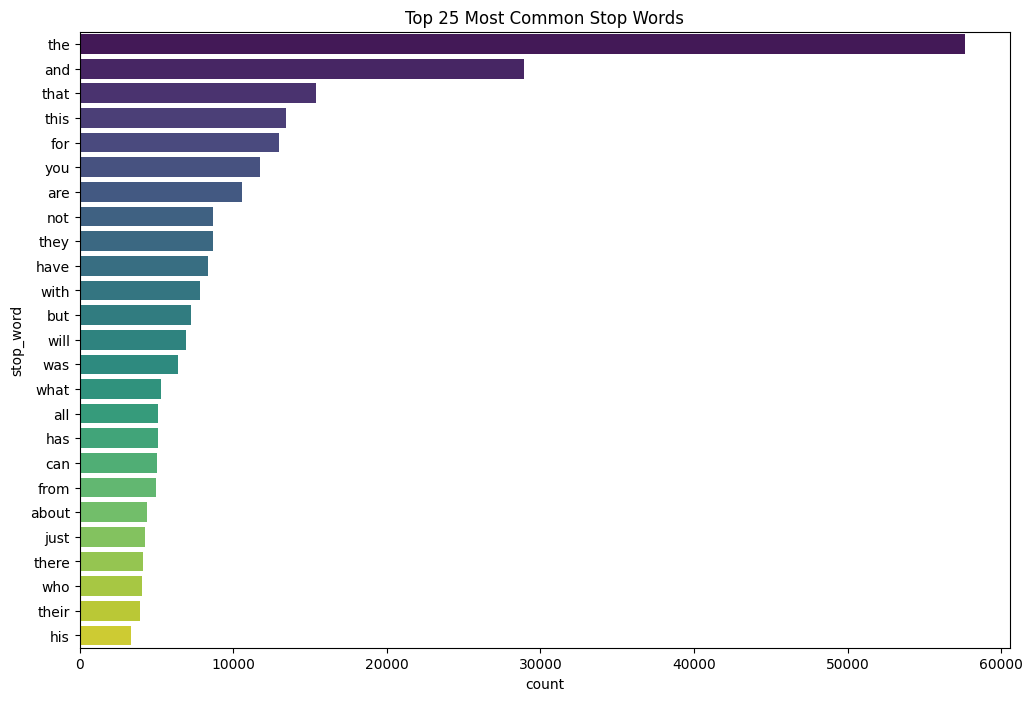

In [27]:
top_stop_words = Counter(w for c in df['clean_comment'] for w in c.split() if w in stop_words).most_common(25)
top_25_df = pd.DataFrame(top_stop_words, columns=['stop_word', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_df, x='count', y='stop_word', hue='stop_word', palette='viridis', legend=False)
plt.title('Top 25 Most Common Stop Words')
plt.show()

## EDA: characters and n-grams

In [28]:
df['num_chars'] = df['clean_comment'].apply(len)
df['num_chars'].describe()

count    36793.000000
mean       181.852798
std        359.702163
min          1.000000
25%         38.000000
50%         80.000000
75%        184.000000
max       8664.000000
Name: num_chars, dtype: float64

In [29]:
# Rare characters include CJK, Arabic and Malayalam script: noise for an English model
char_frequency_df = pd.DataFrame(
    Counter(' '.join(df['clean_comment'])).items(), columns=['character', 'frequency']
).sort_values('frequency', ascending=False)
char_frequency_df.tail(20)

,character,frequency
851,深,1
853,钞,1
854,原,1
856,账,1
797,翠,1
799,郎,1
800,寄,1
801,圆,1
835,希,1
838,招,1


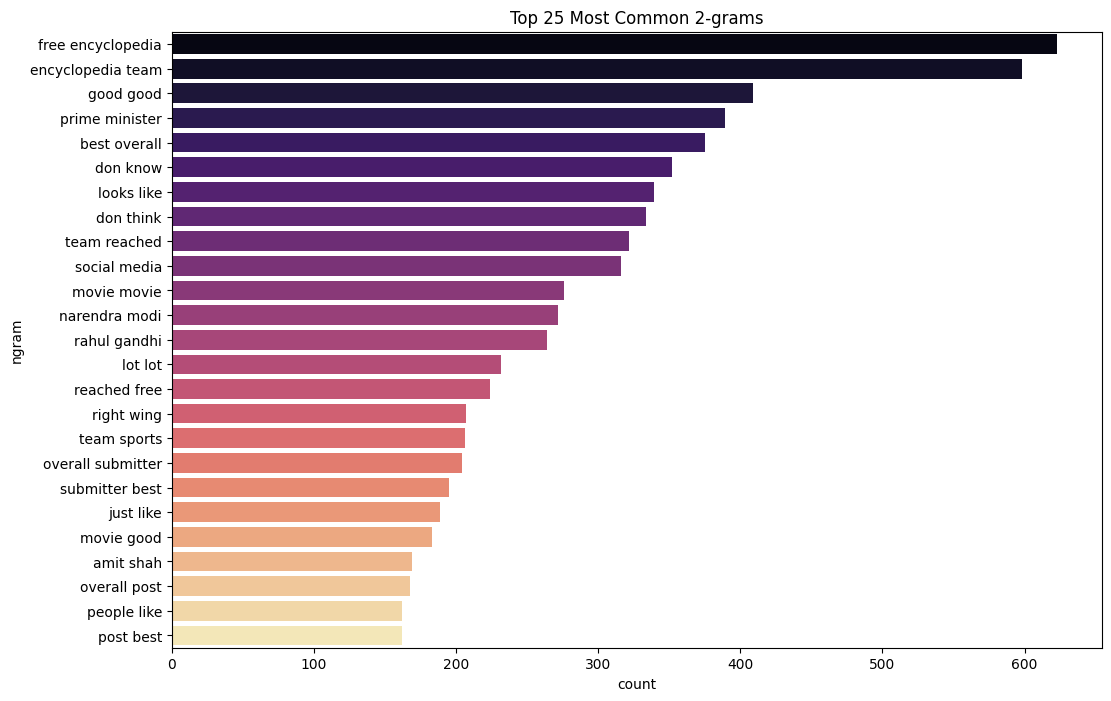

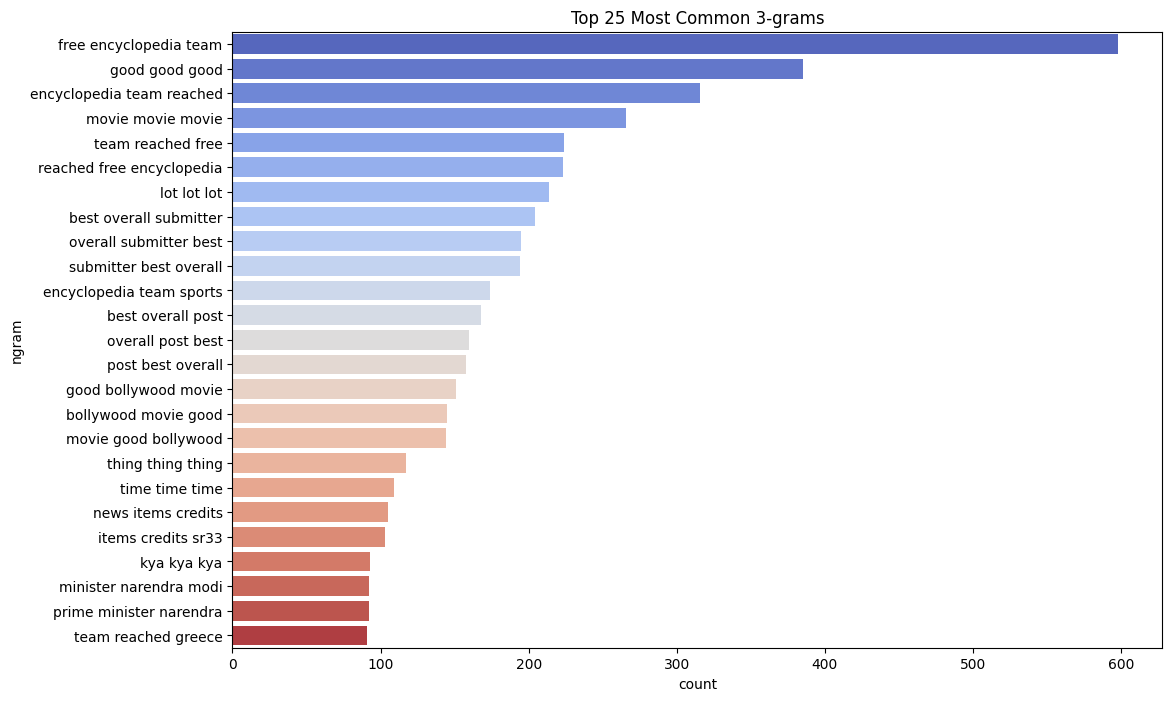

In [30]:
def plot_top_ngrams(corpus, n, top_n=25, palette='magma'):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    counts = vec.transform(corpus).sum(axis=0).A1
    top = sorted(zip(vec.get_feature_names_out(), counts), key=lambda x: x[1], reverse=True)[:top_n]
    top_df = pd.DataFrame(top, columns=['ngram', 'count'])

    plt.figure(figsize=(12, 8))
    sns.barplot(data=top_df, x='count', y='ngram', hue='ngram', palette=palette, legend=False)
    plt.title(f'Top {top_n} Most Common {n}-grams')
    plt.show()


plot_top_ngrams(df['clean_comment'], 2)
plot_top_ngrams(df['clean_comment'], 3, palette='coolwarm')

## Cleaning: non-English characters, stop words, lemmatization

Negations and contrast words (*not, but, however, no, yet*) are kept: "not good" must not become "good".

In [31]:
df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', x))

kept_stop_words = stop_words - {'not', 'but', 'however', 'no', 'yet'}
df['clean_comment'] = df['clean_comment'].apply(lambda x: ' '.join(w for w in x.split() if w not in kept_stop_words))

lemmatizer = WordNetLemmatizer()
df['clean_comment'] = df['clean_comment'].apply(lambda x: ' '.join(lemmatizer.lemmatize(w) for w in x.split()))
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon never tried explain still stare ...,1,39,13,259
1,buddhism much lot compatible christianity espe...,1,196,59,1268
2,seriously say thing first get complex explain ...,-1,86,40,459
3,learned want teach different focus goal not wr...,0,29,15,167
4,benefit may want read living buddha living chr...,1,112,45,690


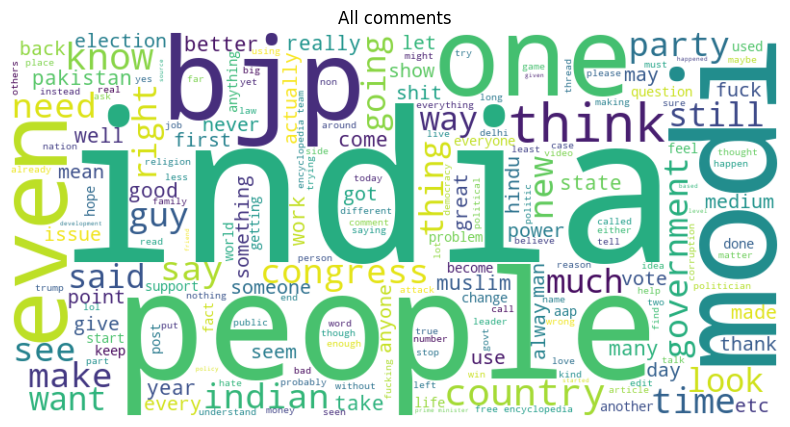

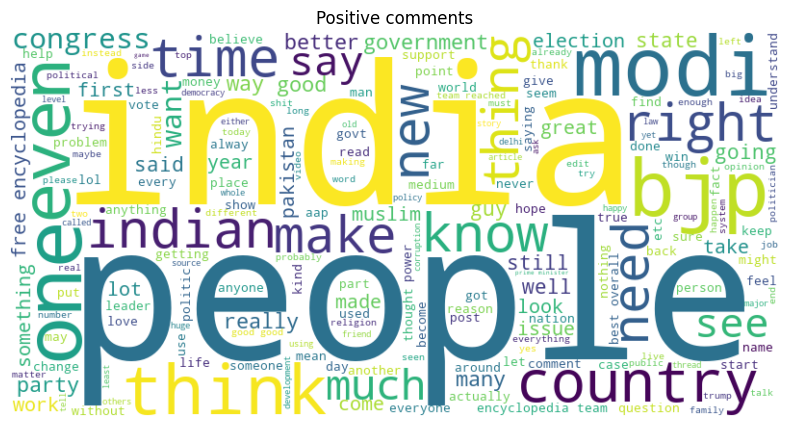

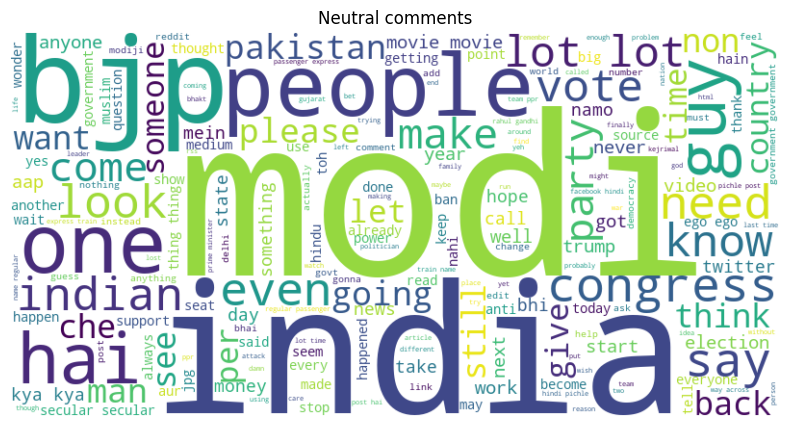

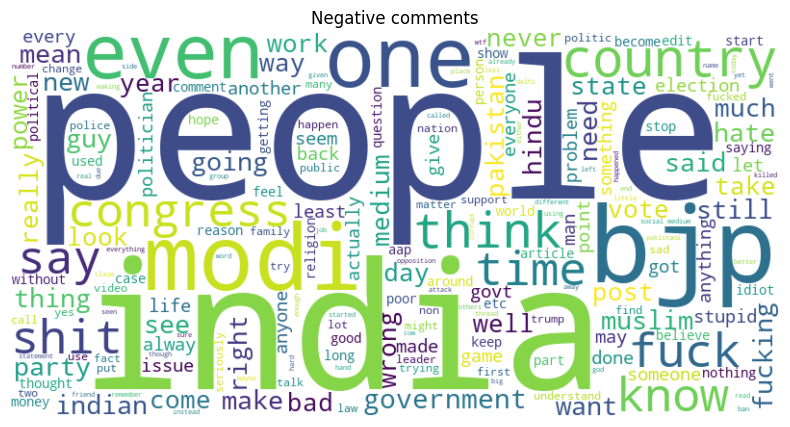

In [32]:
def plot_word_cloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()


plot_word_cloud(df['clean_comment'], 'All comments')
for value, label in [(1, 'Positive'), (0, 'Neutral'), (-1, 'Negative')]:
    plot_word_cloud(df[df['category'] == value]['clean_comment'], f'{label} comments')

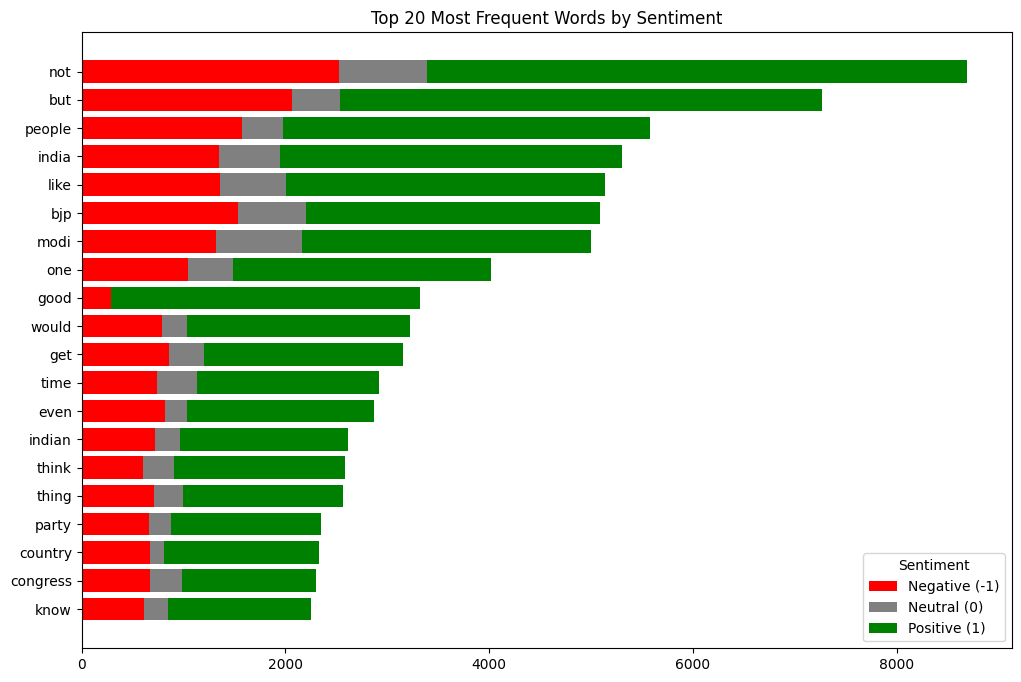

In [33]:
def plot_top_n_words_by_category(df, n=20):
    """Stacked bar chart of the most frequent words, split by sentiment."""
    counts = {-1: Counter(), 0: Counter(), 1: Counter()}
    for comment, category in zip(df['clean_comment'], df['category']):
        counts[category].update(comment.split())

    top_words = [w for w, _ in (counts[-1] + counts[0] + counts[1]).most_common(n)]
    neg = [counts[-1][w] for w in top_words]
    neu = [counts[0][w] for w in top_words]
    pos = [counts[1][w] for w in top_words]

    plt.figure(figsize=(12, 8))
    plt.barh(top_words, neg, color='red', label='Negative (-1)')
    plt.barh(top_words, neu, left=neg, color='gray', label='Neutral (0)')
    plt.barh(top_words, pos, left=[a + b for a, b in zip(neg, neu)], color='green', label='Positive (1)')
    plt.gca().invert_yaxis()
    plt.legend(title='Sentiment', loc='lower right')
    plt.title(f'Top {n} Most Frequent Words by Sentiment')
    plt.show()


plot_top_n_words_by_category(df)

The vocabulary (india, modi, bjp, government) shows the data is mostly Indian political discussion.
A model trained on it will be most accurate on similar comments, and weaker on, say, tech-tutorial videos.